In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
from pathlib import Path

MOUNT_POINT = Path("/content/drive")
MYDRIVE = MOUNT_POINT / "MyDrive"

if MYDRIVE.exists():
    print("Google Drive is already mounted:")
    print(MYDRIVE)
else:
    drive.mount(str(MOUNT_POINT))
    print("Google Drive mounted:")
    print(MYDRIVE)

print("MYDRIVE exists:", MYDRIVE.exists())

Google Drive is already mounted:
/content/drive/MyDrive
MYDRIVE exists: True


In [ ]:
sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.1,
    palette="muted"
)

plt.rcParams["figure.dpi"] = 120

In [ ]:
BASE_DIR = MYDRIVE / "Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step6_probe"

PATH_DIRECT_SCENE_TYPE = (
    BASE_DIR
    / "step6_pilot_full_ithor120_diverse_qwen2_5_3b_pair_explicit_direct_relation_ld_heldout_bathroom_direct_scene_type"
    / "step6_pilot_full_ithor120_diverse_qwen2_5_3b_pair_explicit_direct_relation_ld_heldout_bathroom_direct_scene_type_full_results.json"
)

PATH_SEEN_UNSEEN_DTP = (
    BASE_DIR
    / "step6_pilot_full_ithor120_diverse_qwen2_5_3b_pair_explicit_direct_relation_ld_heldout_bathroom_test_seen_unseen_dtp_only"
    / "step6_pilot_full_ithor120_diverse_qwen2_5_3b_pair_explicit_direct_relation_ld_heldout_bathroom_test_seen_unseen_dtp_only_full_results.json"
)

OUT_DIR = BASE_DIR / "plots_pilot_full_ex_cross_scs_q253b"

OUT_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("BASE_DIR exists:", BASE_DIR.exists())

print("\nPATH_DIRECT_SCENE_TYPE:")
print(PATH_DIRECT_SCENE_TYPE)
print("exists:", PATH_DIRECT_SCENE_TYPE.exists())

print("\nPATH_SEEN_UNSEEN_DTP:")
print(PATH_SEEN_UNSEEN_DTP)
print("exists:", PATH_SEEN_UNSEEN_DTP.exists())

print("\nOUT_DIR:")
print(OUT_DIR)
print("exists:", OUT_DIR.exists())

BASE_DIR: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step6_probe
BASE_DIR exists: True

PATH_DIRECT_SCENE_TYPE:
/content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step6_probe/step6_pilot_full_ithor120_diverse_qwen2_5_3b_pair_explicit_direct_relation_ld_heldout_bathroom_direct_scene_type/step6_pilot_full_ithor120_diverse_qwen2_5_3b_pair_explicit_direct_relation_ld_heldout_bathroom_direct_scene_type_full_results.json
exists: True

PATH_SEEN_UNSEEN_DTP:
/content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step6_probe/step6_pilot_full_ithor120_diverse_qwen2_5_3b_pair_explicit_direct_relation_ld_heldout_bathroom_test_seen_unseen_dtp_only/step6_pilot_full_ithor120_diverse_qwen2_5_3b_pair_explicit_direct_relation_ld_heldout_bathroom_test_seen_unseen_dtp_only_full_results.json
exists: True

OUT_DIR:
/content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step6_probe/

In [ ]:
with open(PATH_DIRECT_SCENE_TYPE, "r", encoding="utf-8") as f:
    direct_scene_type_results = json.load(f)

with open(PATH_SEEN_UNSEEN_DTP, "r", encoding="utf-8") as f:
    seen_unseen_dtp_results = json.load(f)

print("Loaded direct_scene_type experiment:")
print(direct_scene_type_results["experiment"]["experiment_name"])

print("\nLoaded seen_unseen_dtp experiment:")
print(seen_unseen_dtp_results["experiment"]["experiment_name"])

Loaded direct_scene_type experiment:
step6_pilot_full_ithor120_diverse_qwen2_5_3b_pair_explicit_direct_relation_ld_heldout_bathroom_direct_scene_type

Loaded seen_unseen_dtp experiment:
step6_pilot_full_ithor120_diverse_qwen2_5_3b_pair_explicit_direct_relation_ld_heldout_bathroom_test_seen_unseen_dtp_only


In [ ]:
print("direct_scene_type layer_results length:", len(direct_scene_type_results["layer_results"]))
print("seen_unseen_dtp layer_results length:", len(seen_unseen_dtp_results["layer_results"]))

print("\nExample keys in direct_scene_type layer 0:")
print(direct_scene_type_results["layer_results"][0].keys())

print("\nExample keys in seen_unseen_dtp layer 0:")
print(seen_unseen_dtp_results["layer_results"][0].keys())

direct_scene_type layer_results length: 37
seen_unseen_dtp layer_results length: 37

Example keys in direct_scene_type layer 0:
dict_keys(['layer', 'train', 'overall'])

Example keys in seen_unseen_dtp layer 0:
dict_keys(['layer', 'train', 'seen_train_directed_type_pair', 'unseen_train_directed_type_pair'])


In [ ]:
def extract_macro_metrics_from_report(report_dict):
    """
    从 sklearn classification_report 字典中提取 macro avg 指标。
    """
    macro = report_dict["macro avg"]
    return {
        "precision_macro": macro["precision"],
        "recall_macro": macro["recall"],
        "f1_macro": macro["f1-score"],
    }

In [ ]:
rows = []

# 1. direct_scene_type 文件中的 overall 测试结果
for layer_result in direct_scene_type_results["layer_results"]:
    layer = layer_result["layer"]
    overall = layer_result["overall"]

    macro_metrics = extract_macro_metrics_from_report(
        overall["classification_report"]
    )

    rows.append({
        "layer": layer,
        "test_split": "direct_scene_type_overall",
        "accuracy": overall["accuracy"],
        "precision_macro": macro_metrics["precision_macro"],
        "recall_macro": macro_metrics["recall_macro"],
        "f1_macro": macro_metrics["f1_macro"],
        "num_examples": overall["num_examples"],
    })


# 2. seen_unseen_dtp 文件中的 seen / unseen 子测试集
split_mapping = {
    "seen_train_directed_type_pair": "dtp_seen",
    "unseen_train_directed_type_pair": "dtp_unseen",
}

for raw_split_name, display_split_name in split_mapping.items():
    for layer_result in seen_unseen_dtp_results["layer_results"]:
        layer = layer_result["layer"]
        split_result = layer_result[raw_split_name]

        macro_metrics = extract_macro_metrics_from_report(
            split_result["classification_report"]
        )

        rows.append({
            "layer": layer,
            "test_split": display_split_name,
            "accuracy": split_result["accuracy"],
            "precision_macro": macro_metrics["precision_macro"],
            "recall_macro": macro_metrics["recall_macro"],
            "f1_macro": macro_metrics["f1_macro"],
            "num_examples": split_result["num_examples"],
        })


df_three_curves = pd.DataFrame(rows)
df_three_curves = df_three_curves.sort_values(["test_split", "layer"]).reset_index(drop=True)

df_three_curves.head()

,layer,test_split,accuracy,precision_macro,recall_macro,f1_macro,num_examples
0,0,direct_scene_type_overall,0.252026,0.306715,0.263992,0.233845,4690
1,1,direct_scene_type_overall,0.526439,0.530338,0.540326,0.513861,4690
2,2,direct_scene_type_overall,0.601706,0.582660,0.598913,0.575066,4690
3,3,direct_scene_type_overall,0.623881,0.583554,0.619333,0.592071,4690
4,4,direct_scene_type_overall,0.605544,0.592753,0.576864,0.577404,4690


In [ ]:
csv_three_curves_path = OUT_DIR / "layerwise_metrics_overall_seen_unseen.csv"
df_three_curves.to_csv(csv_three_curves_path, index=False)

print("Saved:", csv_three_curves_path)
display(df_three_curves.head(10))

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step6_probe/plots_pilot_full_ex_cross_scs_q253b/layerwise_metrics_overall_seen_unseen.csv


,layer,test_split,accuracy,precision_macro,recall_macro,f1_macro,num_examples
0,0,direct_scene_type_overall,0.252026,0.306715,0.263992,0.233845,4690
1,1,direct_scene_type_overall,0.526439,0.530338,0.540326,0.513861,4690
2,2,direct_scene_type_overall,0.601706,0.582660,0.598913,0.575066,4690
3,3,direct_scene_type_overall,0.623881,0.583554,0.619333,0.592071,4690
4,4,direct_scene_type_overall,0.605544,0.592753,0.576864,0.577404,4690
5,5,direct_scene_type_overall,0.625160,0.618978,0.604796,0.599279,4690
6,6,direct_scene_type_overall,0.552665,0.576465,0.542741,0.542743,4690
7,7,direct_scene_type_overall,0.533049,0.572797,0.517992,0.527375,4690
8,8,direct_scene_type_overall,0.505757,0.542985,0.502092,0.504142,4690
9,9,direct_scene_type_overall,0.514712,0.519452,0.508460,0.499598,4690


In [ ]:
METRIC_CONFIG = {
    "accuracy": "Accuracy",
    "precision_macro": "Macro Precision",
    "recall_macro": "Macro Recall",
    "f1_macro": "Macro F1",
}

FONT_CONFIG = {
    "title": 22,
    "axis_label": 16,
    "tick_label": 16,
    "legend_title": 16,
    "legend_text": 16,
    "annotation": 14,
}

# 每个指标下，对三条曲线的最高点标注框设置不同偏移，避免重叠
# xytext 的单位是 points: (水平偏移, 垂直偏移)
ANNOTATION_OFFSETS_BY_METRIC = {
    "accuracy": {
        "dtp_seen": (12, 10),
        "direct_scene_type_overall": (8, 32),
        "dtp_unseen": (8, -50),
    },
    "precision_macro": {
        "dtp_seen": (8, 15),
        "direct_scene_type_overall": (19, 20),
        "dtp_unseen": (8, -42),
    },
    "recall_macro": {
        "dtp_seen": (8, 12),
        "direct_scene_type_overall": (-82, -50),
        "dtp_unseen": (8, -45),
    },
    "f1_macro": {
        "dtp_seen": (8, 15),
        "direct_scene_type_overall": (8, 25),
        "dtp_unseen": (8, -50),
    },
}


def plot_layerwise_metric_seaborn(
    df,
    metric,
    split_col="test_split",
    out_dir=OUT_DIR,
    title_prefix="Layerwise Performance by Test Split",
):
    """
    使用 seaborn 绘制某一个指标的逐层折线图。

    功能：
    - 绘制三条曲线：direct_scene_type_overall / dtp_seen / dtp_unseen
    - 图例放在图表内部右下角
    - 纵轴刻度间隔为 0.1
    - 分别标出每条曲线的最高点
    - 用竖向虚线标出最高点所在 layer
    - 在最高点附近标注 layer 与数值
    """
    metric_label = METRIC_CONFIG[metric]

    plt.figure(figsize=(18, 6))

    ax = sns.lineplot(
        data=df,
        x="layer",
        y=metric,
        hue=split_col,
        marker="o",
        linewidth=2.0
    )

    # 标题与坐标轴字号
    ax.set_xlabel("Layer", fontsize=FONT_CONFIG["axis_label"])
    ax.set_ylabel(metric_label, fontsize=FONT_CONFIG["axis_label"])
    ax.set_title(
        f"{title_prefix}: {metric_label}",
        fontsize=FONT_CONFIG["title"],
        pad=12
    )

    # 横轴与纵轴刻度
    ax.set_xticks(sorted(df["layer"].unique()))
    ax.set_ylim(0.0, 1.0)
    ax.set_yticks(np.arange(0.0, 1.01, 0.1))

    ax.tick_params(
        axis="both",
        labelsize=FONT_CONFIG["tick_label"]
    )

    # 取得 seaborn 自动分配给每条线的颜色
    handles, labels = ax.get_legend_handles_labels()
    color_map = {
        label: handle.get_color()
        for label, handle in zip(labels, handles)
        if label != split_col
    }

    annotation_offsets = ANNOTATION_OFFSETS_BY_METRIC.get(metric, {})

    # 分别标出每条曲线的最高点
    for split_name, sub_df in df.groupby(split_col):
        sub_df = sub_df.sort_values("layer").reset_index(drop=True)

        # 如果有多个相同最高值，idxmax 默认取第一个
        max_idx = sub_df[metric].idxmax()
        max_layer = sub_df.loc[max_idx, "layer"]
        max_value = sub_df.loc[max_idx, metric]

        line_color = color_map.get(split_name, "gray")

        # 竖向虚线：最高点所在 layer
        ax.axvline(
            x=max_layer,
            linestyle="--",
            linewidth=1.4,
            alpha=0.8,
            color=line_color
        )

        # 最高点 marker
        ax.scatter(
            max_layer,
            max_value,
            s=120,
            color=line_color,
            edgecolor="black",
            linewidth=1.0,
            zorder=5
        )

        # 标注最高点
        DISPLAY_NAME_MAP = {
            "dtp_seen": "seen",
            "direct_scene_type_overall": "overall",
            "dtp_unseen": "unseen",
            }
        display_name = DISPLAY_NAME_MAP.get(split_name, split_name)

        ax.annotate(
            f"{display_name}\nL{int(max_layer)}: {max_value:.3f}",
            xy=(max_layer, max_value),
            xytext=annotation_offsets.get(split_name, (8, 10)),
            textcoords="offset points",
            fontsize=FONT_CONFIG["annotation"],
            color=line_color,
            bbox=dict(
                boxstyle="round,pad=0.25",
                fc="white",
                ec=line_color,
                alpha=0.90
                ),
            )

    # 图例放在图表内部右下角
    ax.legend(
        title=split_col,
        loc="lower right",
        frameon=True,
        fontsize=FONT_CONFIG["legend_text"],
        title_fontsize=FONT_CONFIG["legend_title"],
    )

    plt.tight_layout()

    out_path = out_dir / f"layerwise_{metric}_overall_seen_unseen_seaborn.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)
    return out_path

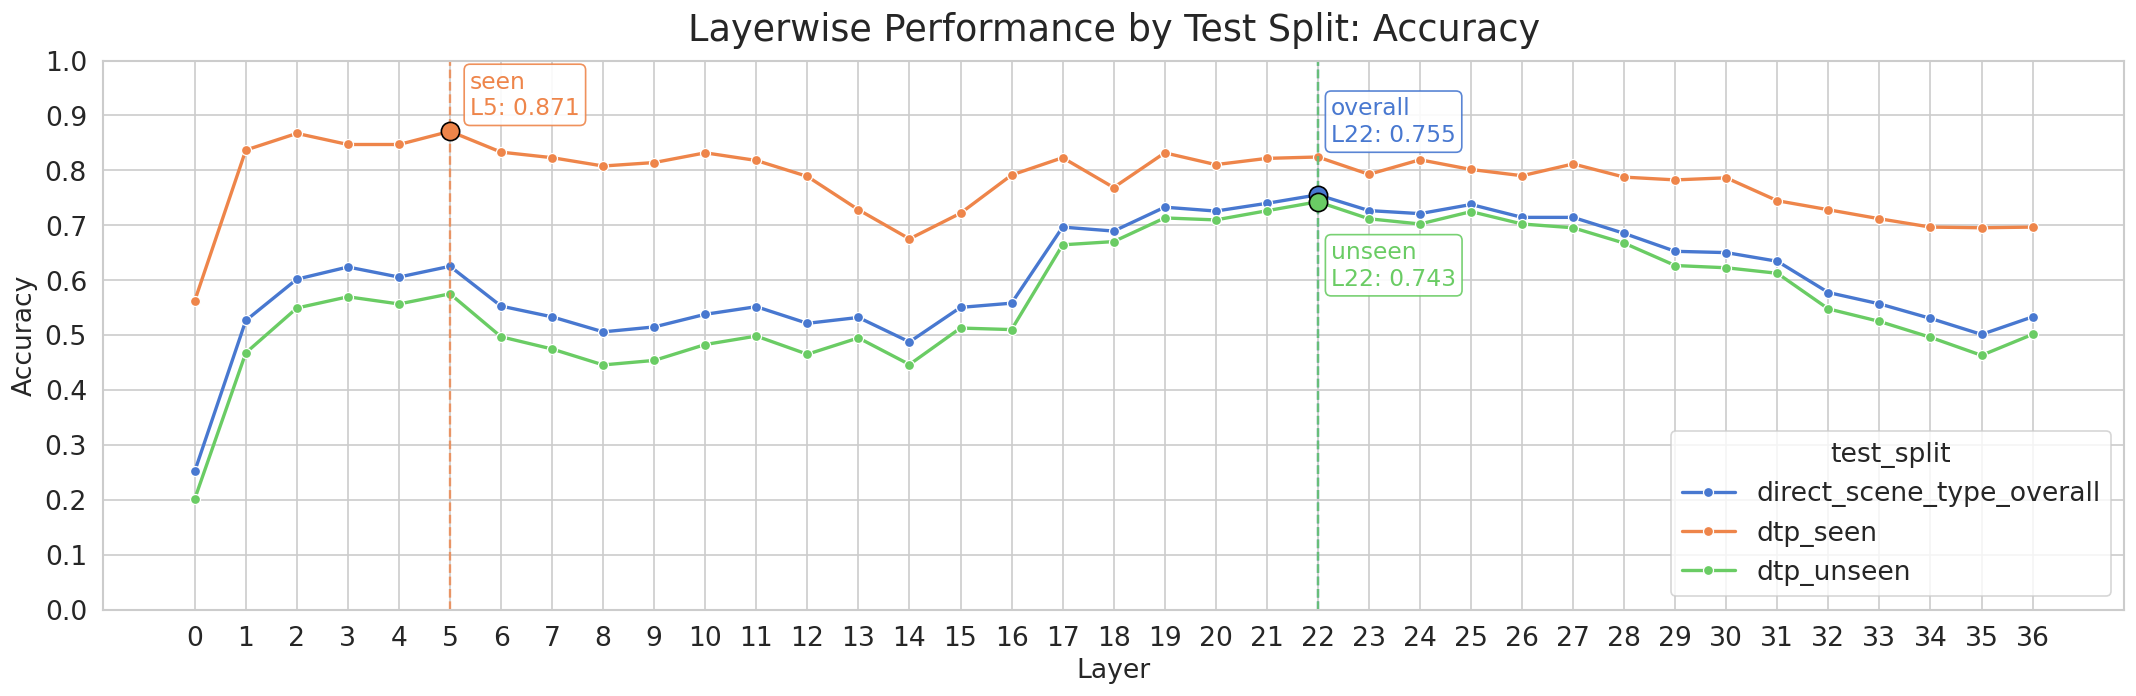

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step6_probe/plots_pilot_full_ex_cross_scs_q253b/layerwise_accuracy_overall_seen_unseen_seaborn.png


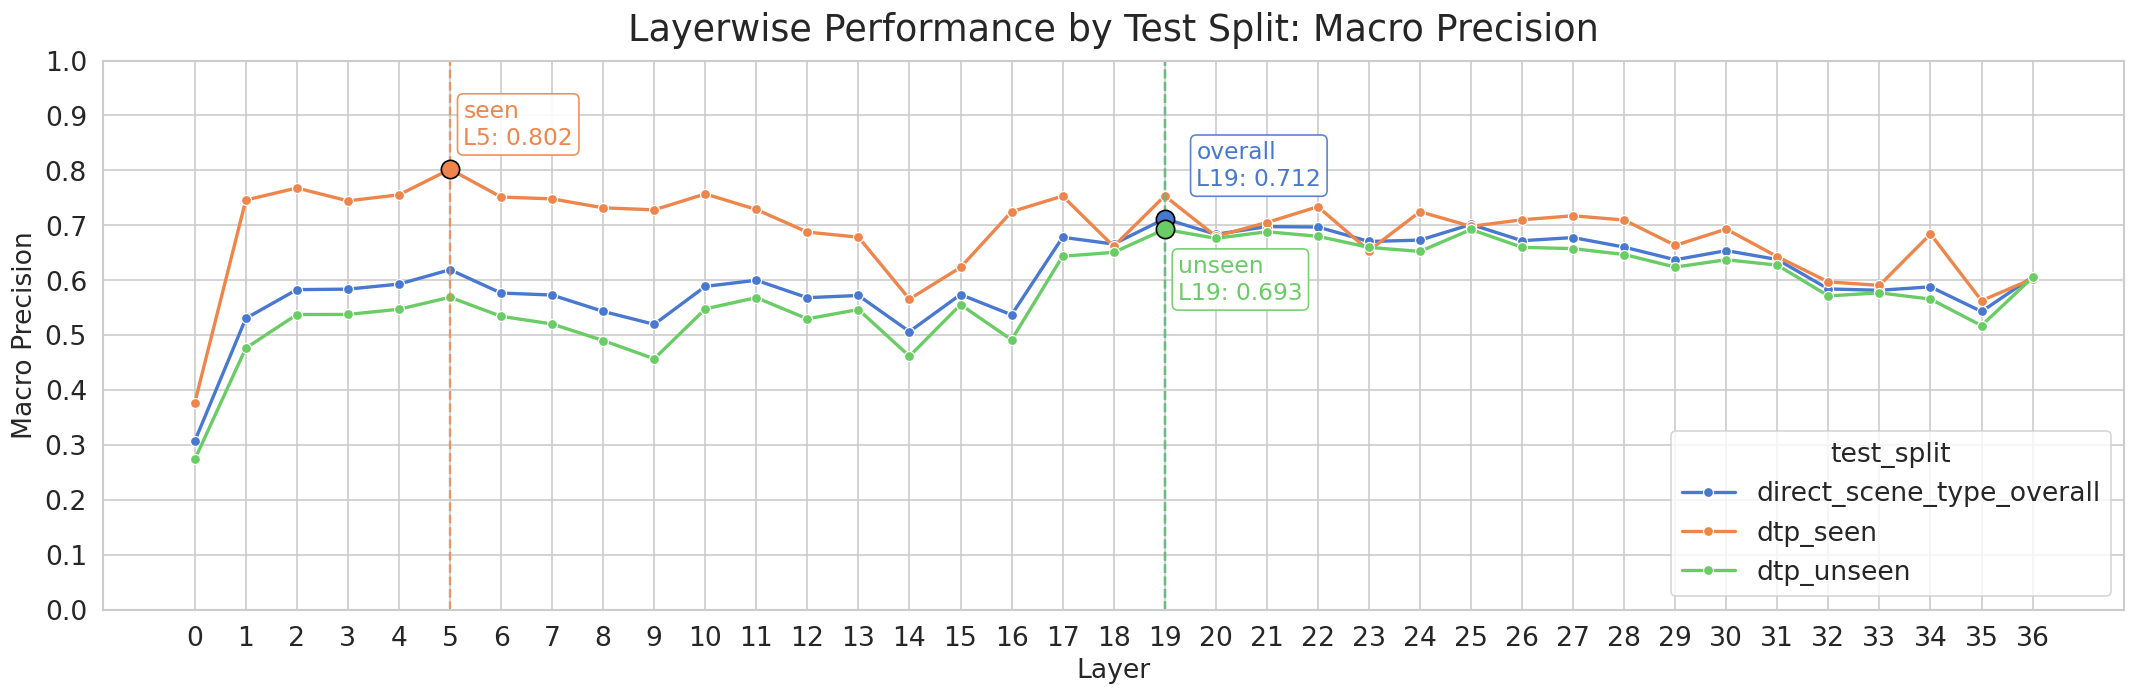

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step6_probe/plots_pilot_full_ex_cross_scs_q253b/layerwise_precision_macro_overall_seen_unseen_seaborn.png


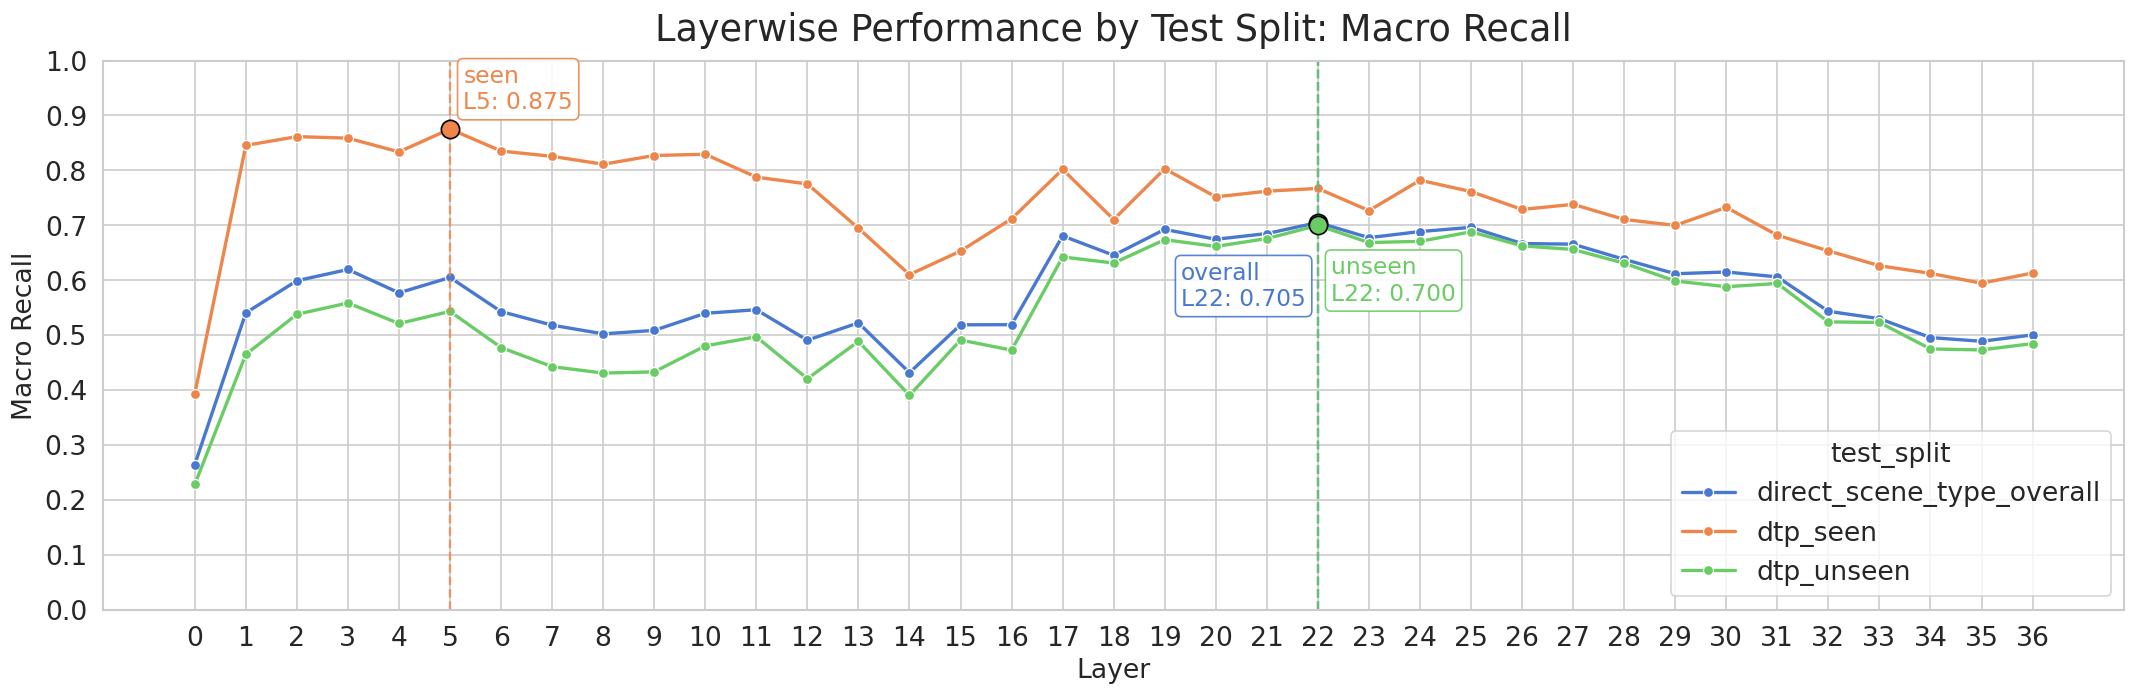

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step6_probe/plots_pilot_full_ex_cross_scs_q253b/layerwise_recall_macro_overall_seen_unseen_seaborn.png


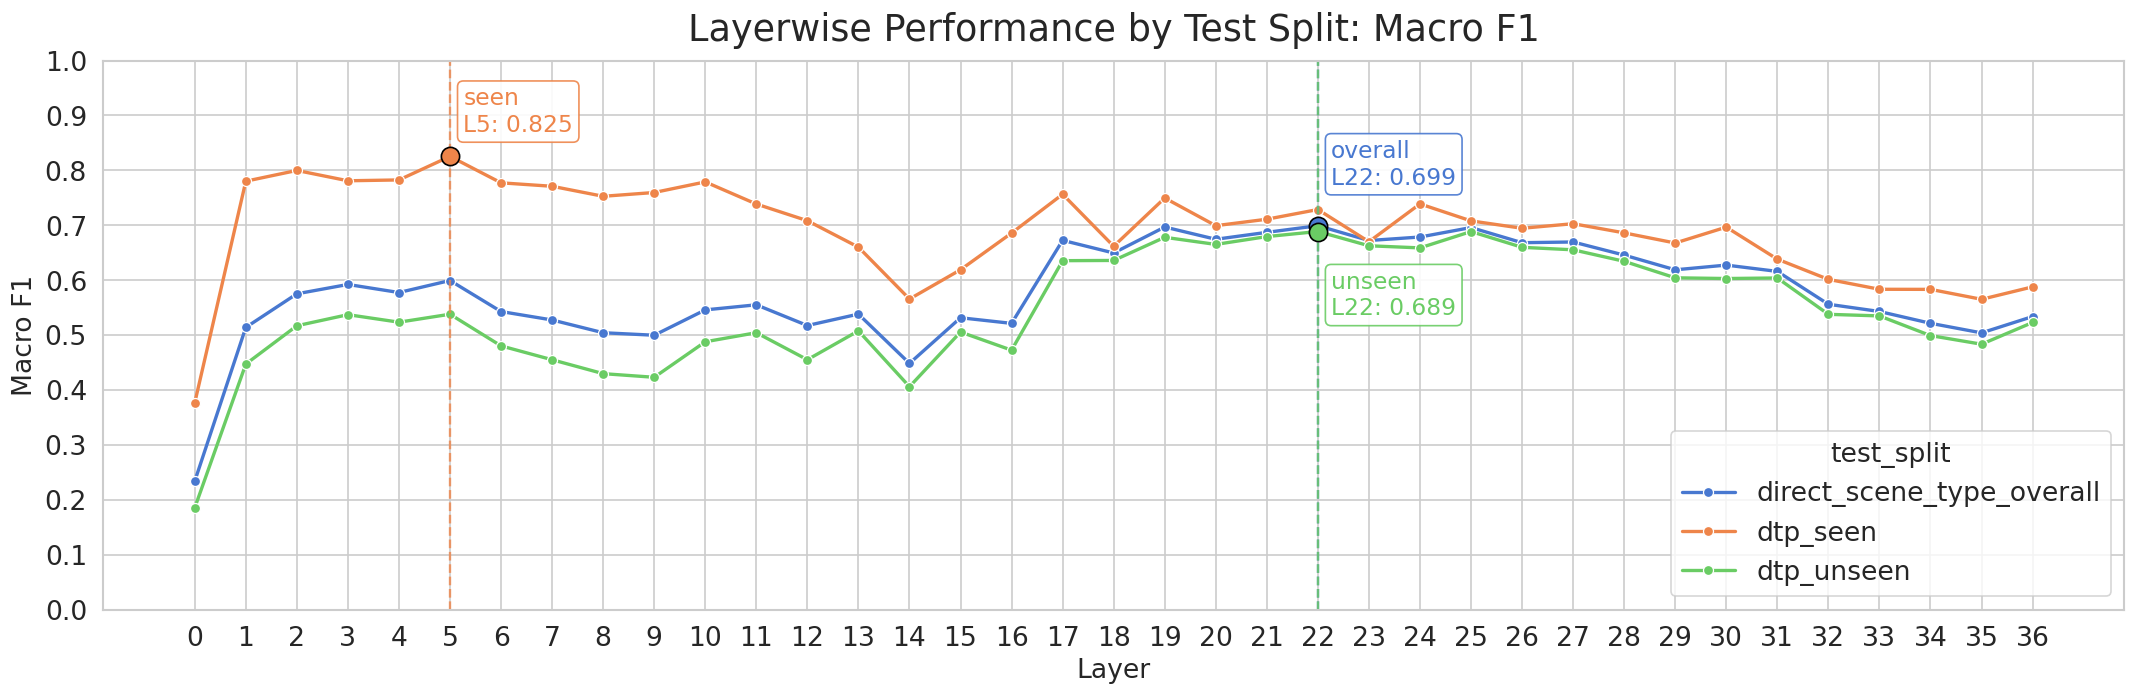

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step6_probe/plots_pilot_full_ex_cross_scs_q253b/layerwise_f1_macro_overall_seen_unseen_seaborn.png


{'accuracy': PosixPath('/content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step6_probe/plots_pilot_full_ex_cross_scs_q253b/layerwise_accuracy_overall_seen_unseen_seaborn.png'),
 'precision_macro': PosixPath('/content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step6_probe/plots_pilot_full_ex_cross_scs_q253b/layerwise_precision_macro_overall_seen_unseen_seaborn.png'),
 'recall_macro': PosixPath('/content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step6_probe/plots_pilot_full_ex_cross_scs_q253b/layerwise_recall_macro_overall_seen_unseen_seaborn.png'),
 'f1_macro': PosixPath('/content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step6_probe/plots_pilot_full_ex_cross_scs_q253b/layerwise_f1_macro_overall_seen_unseen_seaborn.png')}

In [ ]:
plot_paths_three_curves = {}

for metric in METRIC_CONFIG:
    out_path = plot_layerwise_metric_seaborn(
        df=df_three_curves,
        metric=metric,
        split_col="test_split",
        out_dir=OUT_DIR,
        )
    plot_paths_three_curves[metric] = out_path

plot_paths_three_curves

In [ ]:
from google.colab import files
import zipfile

ZIP_PATH = OUT_DIR / "layerwise_metric_plots_overall_seen_unseen.zip"

patterns = [
    "*_overall_seen_unseen_seaborn.png",
    "layerwise_metrics_overall_seen_unseen.csv",
]

output_files = []
for pattern in patterns:
    output_files.extend(sorted(OUT_DIR.glob(pattern)))

print("Found files:")
for p in output_files:
    print("-", p.name)

if len(output_files) == 0:
    raise FileNotFoundError(
        f"No output files found in {OUT_DIR}. "
        "Please run the plotting cells first."
    )

with zipfile.ZipFile(ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for file_path in output_files:
        zf.write(file_path, arcname=file_path.name)

print("Created zip file:")
print(ZIP_PATH)

files.download(str(ZIP_PATH))

Found files:
- layerwise_accuracy_overall_seen_unseen_seaborn.png
- layerwise_f1_macro_overall_seen_unseen_seaborn.png
- layerwise_precision_macro_overall_seen_unseen_seaborn.png
- layerwise_recall_macro_overall_seen_unseen_seaborn.png
- layerwise_metrics_overall_seen_unseen.csv
Created zip file:
/content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step6_probe/plots_pilot_full_ex_cross_scs_q253b/layerwise_metric_plots_overall_seen_unseen.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>